In [464]:
import warnings
warnings.filterwarnings("ignore", message="Could not find the number of physical cores")


In [465]:
import pandas as pd
import numpy as np
import re
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.linear_model import LogisticRegression





In [466]:
df = pd.read_csv("ML1404_dataset - ML1404_dataset.csv")

In [467]:
df

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas
...,...,...,...,...,...,...,...,...
12995,Amir,Jafari,Talent Acquisition and People Partner,sales & marketing supervisor in renew transpor...,Mammut Diesel (Exclusive Partner of Scania Tru...,Oct 2004 - Present · 19 yrs 11 mos,"Tehran, Iran",NaN
12996,Mahdi,Momeni,Frontend Engineer at Digikala,Sales Manager,Mammut World Panel Conex · Full-time,Oct 2004 - Present · 19 yrs 11 mos,Iran · On-site,Mammut Structures & Panel
12997,Fateme,Najafi,Sr. Data Scientist @ Theory+Practice | Data An...,sales & marketing supervisor in prefabricated ...,Mammut group,Jul 2003 - Present · 21 yrs 2 mos,"Alborz Province, Iran",NaN
12998,Mohammad,Ahmadzadeh,Cybersecurity Researcher | Penetration Test,Founder,SQUARED inc.,Sep 2023 - Present · 1 yr,"Ontario, Canada",SQUARED inc.


In [468]:
df[df['duration_of_cooperation'].isnull()==True]

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name
11,sadegh,farahani,--,Chidaneh,Full-time · 2 yrs 8 mos,NaN,NaN,Chidaneh
24,Ava,Amirfazli,Offline Marketing Specialist,Chidaneh,Full-time · 2 yrs 8 mos,NaN,NaN,Chidaneh
37,Bita,Farahani,Physical Chemistry,Chidaneh,Full-time · 2 yrs 8 mos,NaN,NaN,Chidaneh
54,Pariya,Sayadi,performance specialist at @digikala.com,Mobinnet,13 yrs 4 mos,NaN,NaN,mobinnet|مبین‌نت
56,Seyed Mohsen,Zarei,Technical Specialist at Tunnel Sadd Ariana Com...,Simaresana Co.,5 yrs,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
12958,mohamad saleh,shojai,student ce sharif,TondAhil,Self-employed · 4 mos,NaN,NaN,TondAhil
12966,Abolfazl,Talaei,Software Engineer @ Digikala,Sayesaman.Co,Full-time · 7 yrs 11 mos,NaN,NaN,Sayesaman.Co
12969,Sina,Dehghanian,‪Data Analyst & Engineer | Python Hobbyist | e...,Deputy Complex manager,Arak Petrochemical Company,NaN,NaN,Arak Petrochemical Company
12982,EU MDR,Compliance,Take control of medical device compliance | Te...,Behpardaz Hamrah Samaneh Aval (Behsa),5 yrs 9 mos,NaN,NaN,Behpardaz Hamrah Samaneh Aval (Behsa)


In [469]:
df

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas
...,...,...,...,...,...,...,...,...
12995,Amir,Jafari,Talent Acquisition and People Partner,sales & marketing supervisor in renew transpor...,Mammut Diesel (Exclusive Partner of Scania Tru...,Oct 2004 - Present · 19 yrs 11 mos,"Tehran, Iran",NaN
12996,Mahdi,Momeni,Frontend Engineer at Digikala,Sales Manager,Mammut World Panel Conex · Full-time,Oct 2004 - Present · 19 yrs 11 mos,Iran · On-site,Mammut Structures & Panel
12997,Fateme,Najafi,Sr. Data Scientist @ Theory+Practice | Data An...,sales & marketing supervisor in prefabricated ...,Mammut group,Jul 2003 - Present · 21 yrs 2 mos,"Alborz Province, Iran",NaN
12998,Mohammad,Ahmadzadeh,Cybersecurity Researcher | Penetration Test,Founder,SQUARED inc.,Sep 2023 - Present · 1 yr,"Ontario, Canada",SQUARED inc.


In [470]:

pattern = re.compile(
    r'(\d+\s*(?:yr|yrs))?(\s*\d+\s*mos)?',
    flags=re.IGNORECASE
)

def matches_experience_pattern(value):
    if pd.isnull(value):
        return False
    matches = pattern.findall(str(value))
    return any('yr' in match[0].lower() or 'mos' in match[1].lower() for match in matches if match)



In [471]:
for c in df.columns:
    matched_rows = df[df[c].apply(matches_experience_pattern)]
    print('\n###################################\n',f'for {c} \n',matched_rows[['first_name', 'last_name','headline','job_title','location_hybrid','company_name','time_type_full_or_part','duration_of_cooperation']])



###################################
 for first_name 
 Empty DataFrame
Columns: [first_name, last_name, headline, job_title, location_hybrid, company_name, time_type_full_or_part, duration_of_cooperation]
Index: []

###################################
 for last_name 
 Empty DataFrame
Columns: [first_name, last_name, headline, job_title, location_hybrid, company_name, time_type_full_or_part, duration_of_cooperation]
Index: []

###################################
 for headline 
       first_name last_name                                           headline  \
11893    Nazanin  Teymoori  Tech SEO Executive with +6 yrs Exp | Consultin...   

                job_title location_hybrid company_name time_type_full_or_part  \
11893  Founder & Designer    Iran, Tehran    ZagStudio              ZagStudio   

              duration_of_cooperation  
11893  Mar 2013 - 2018 · 4 yrs 11 mos  

###################################
 for job_title 
 Empty DataFrame
Columns: [first_name, last_name, headline,

In [472]:
11141 + 1578

12719

In [473]:
df.iloc[11893]

first_name                                                           Nazanin
last_name                                                           Teymoori
headline                   Tech SEO Executive with +6 yrs Exp | Consultin...
job_title                                                 Founder & Designer
time_type_full_or_part                                             ZagStudio
duration_of_cooperation                       Mar 2013 - 2018 · 4 yrs 11 mos
location_hybrid                                                 Iran, Tehran
company_name                                                       ZagStudio
Name: 11893, dtype: object

In [474]:
df.iloc[12960]

first_name                                                       Hossein
last_name                                                        Sadeghi
headline                   CEO at Pardazeshgaran Behin Sayar (sayar.org)
job_title                                                     Ebrahim Co
time_type_full_or_part                          Full-time · 4 yrs 10 mos
duration_of_cooperation                                          On-site
location_hybrid                                                      NaN
company_name                                  Ebrahim Co. Ltd. | ابراهیم
Name: 12960, dtype: object

In [475]:

def is_valid_duration(value):
    if pd.isna(value):
        return False
    return bool(pd.Series(value).str.contains(r'\d+\s(yr|yrs|mos|mo)', regex=True).iloc[0])

df['duration_of_cooperation'] = df.apply(
    lambda row: row['time_type_full_or_part'] if not is_valid_duration(row['duration_of_cooperation']) else row['duration_of_cooperation'],
    axis=1
)


C:\Users\hwi\AppData\Local\Temp\ipykernel_10980\3252874121.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return bool(pd.Series(value).str.contains(r'\d+\s(yr|yrs|mos|mo)', regex=True).iloc[0])


In [476]:
    matched_rows = df[df['duration_of_cooperation'].apply(matches_experience_pattern)]
    print(matched_rows[['first_name', 'last_name', 'time_type_full_or_part','duration_of_cooperation']])

      first_name   last_name  \
0       Mohammad      Khezri   
1        mohamad       Imani   
2           Azin    Ehsanian   
3          Mahdi     Bagheri   
4           Sara     Sadeghi   
...          ...         ...   
12995       Amir      Jafari   
12996      Mahdi      Momeni   
12997     Fateme      Najafi   
12998   Mohammad  Ahmadzadeh   
12999     Ahmad       Abbasi   

                                  time_type_full_or_part  \
0                                     Pixune · Freelance   
1                                Cofinfo · Self-employed   
2                                   Karnakon · Full-time   
3                  Forex Trading Online · Apprenticeship   
4               Home Design Decoration ideas · Part-time   
...                                                  ...   
12995  Mammut Diesel (Exclusive Partner of Scania Tru...   
12996               Mammut World Panel Conex · Full-time   
12997                                       Mammut group   
12998          

In [477]:

def is_valid_duration(value):
    if pd.isna(value):
        return False
    return bool(pd.Series(value).str.contains(r'\d+\s*(yr|yrs|mo|mos)', regex=True).iloc[0])

invalid_durations = df[~df['duration_of_cooperation'].apply(is_valid_duration)]
print(f"invalid_durations {len(invalid_durations)}")


C:\Users\hwi\AppData\Local\Temp\ipykernel_10980\2896877962.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return bool(pd.Series(value).str.contains(r'\d+\s*(yr|yrs|mo|mos)', regex=True).iloc[0])


invalid_durations 187


In [478]:
df[df['duration_of_cooperation'].isnull()==True]

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name
96,Mahdi,Haghighat,Senior Data Engineer | Senior Java Developer |...,NaN,NaN,NaN,NaN,NaN
97,Mehran,Khorrami,Senior Front-end Developer | Full Stack Web De...,NaN,NaN,NaN,NaN,NaN
804,Shaghayegh,Heydari,Software System Analyst,NaN,NaN,NaN,NaN,NaN
990,Samira,Dadashi,Product manager,NaN,NaN,NaN,NaN,NaN
1811,Hamid,Parsa,Broker at Century 21 Atria Top Choice Team,Amutor,NaN,NaN,NaN,NaN
1812,Shima,Sedghi,Forex Trader,Amutor,NaN,NaN,NaN,NaN
1813,AmirMohsen,KarimiMajd,Senior Product Manager,Amutor,NaN,NaN,NaN,NaN
4965,Seied Mostafa,Mirmahdi,strategy manager,NaN,NaN,NaN,NaN,NaN
7553,Milad,Bafarassat,Ex-Tech Product Manager | Transitioning to Com...,expert,NaN,NaN,NaN,NaN
8044,Mohadese,Nemati,Business Analyst supervisor at SnappFood,expert,NaN,NaN,NaN,NaN


In [479]:
df = df.dropna(subset=['duration_of_cooperation'])


In [480]:
df['duration_of_cooperation']

0           Jul 2022 - Present · 2 yrs 1 mo
1           Dec 2022 - Present · 1 yr 8 mos
2          Dec 2020 - Aug 2022 · 1 yr 9 mos
3          Apr 2020 - Present · 4 yrs 4 mos
4          Jan 2018 - Present · 6 yrs 7 mos
                        ...                
12995    Oct 2004 - Present · 19 yrs 11 mos
12996    Oct 2004 - Present · 19 yrs 11 mos
12997     Jul 2003 - Present · 21 yrs 2 mos
12998             Sep 2023 - Present · 1 yr
12999      May 2022 - Present · 2 yrs 4 mos
Name: duration_of_cooperation, Length: 12985, dtype: object

In [481]:
def is_valid_duration(value):
    if pd.isna(value):
        return False
    pattern = r'(\d+\s*(yr|yrs|mo|mos))'
    return bool(re.search(pattern, str(value)))

invalid_rows = df[~df['duration_of_cooperation'].apply(is_valid_duration)]

print(invalid_rows[['duration_of_cooperation','first_name','time_type_full_or_part']])


                           duration_of_cooperation     first_name  \
66                                            SITS        Sepehr    
90                             Irangan · Full-time          shima   
95     Varanegar Pishro | ورانگر پیشرو · Full-time          Mahsa   
265                             Amazon · Part-time           Omid   
442                             پردازشگران نواندیش  Mohammad Reza   
...                                            ...            ...   
12597                                         Fava         Nasrin   
12720                               tadbir company           Omid   
12805                                 organization         Shayan   
12831                    Sana Andisheh · Full-time         Marjan   
12969                   Arak Petrochemical Company           Sina   

                            time_type_full_or_part  
66                                            SITS  
90                             Irangan · Full-time  
95     Varan

In [482]:
df.iloc[66]

first_name                                                      Sepehr 
last_name                                                       Saghari
headline                   CEO & Co-founder at Nimaad | Medical Devices
job_title                                       Virtualization Engineer
time_type_full_or_part                                             SITS
duration_of_cooperation                                            SITS
location_hybrid                                                     NaN
company_name                                                       SITS
Name: 66, dtype: object

In [483]:
df.columns

Index(['first_name', 'last_name', 'headline', 'job_title',
       'time_type_full_or_part', 'duration_of_cooperation', 'location_hybrid',
       'company_name'],
      dtype='object')

In [484]:
df_cleaned = df[df['duration_of_cooperation'].apply(is_valid_duration)]


In [485]:
df_cleaned

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas
...,...,...,...,...,...,...,...,...
12995,Amir,Jafari,Talent Acquisition and People Partner,sales & marketing supervisor in renew transpor...,Mammut Diesel (Exclusive Partner of Scania Tru...,Oct 2004 - Present · 19 yrs 11 mos,"Tehran, Iran",NaN
12996,Mahdi,Momeni,Frontend Engineer at Digikala,Sales Manager,Mammut World Panel Conex · Full-time,Oct 2004 - Present · 19 yrs 11 mos,Iran · On-site,Mammut Structures & Panel
12997,Fateme,Najafi,Sr. Data Scientist @ Theory+Practice | Data An...,sales & marketing supervisor in prefabricated ...,Mammut group,Jul 2003 - Present · 21 yrs 2 mos,"Alborz Province, Iran",NaN
12998,Mohammad,Ahmadzadeh,Cybersecurity Researcher | Penetration Test,Founder,SQUARED inc.,Sep 2023 - Present · 1 yr,"Ontario, Canada",SQUARED inc.


In [486]:

df = df.copy()

df['duration_of_cooperation_clean'] = (
    df['duration_of_cooperation']
      .str.replace('[–—−]', '-', regex=True)
      .str.replace('\s+', ' ', regex=True)
      .str.replace('(?i)present', 'Present', regex=True)
      .str.strip()
)

pattern_full = r'(?P<start>[A-Za-z]{3} \d{4})\s*-\s*(?P<end>Present|[A-Za-z]{3} \d{4})\s*[·•]\s*(?P<duration>.+)'
extracted_full = df['duration_of_cooperation_clean'].str.extract(pattern_full)

pattern_duration_only = r'(?P<duration_only>\d+\s*(yrs?|mos?)(\s+\d+\s*mos?)?)'
extracted_duration = df['duration_of_cooperation_clean'].str.extract(pattern_duration_only)

df['duration_text'] = extracted_full['duration'].combine_first(extracted_duration['duration_only'])


df['start_date'] = pd.to_datetime(extracted_full['start'], format='%b %Y', errors='coerce')
df['end_date'] = extracted_full['end'].apply(lambda x: pd.Timestamp(datetime.today().date()) if x == 'Present' else pd.to_datetime(x, format='%b %Y', errors='coerce'))

df['start_date'] = df['start_date'].dt.strftime('%d/%m/%Y')
df['end_date'] = df['end_date'].dt.strftime('%d/%m/%Y')


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\hwi\AppData\Local\Temp\ipykernel_10980\641511493.py:6: SyntaxWarning: invalid escape sequence '\s'
  .str.replace('\s+', ' ', regex=True)


In [487]:
df.head()

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,start_date,end_date
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN,Jul 2022 - Present · 2 yrs 1 mo,2 yrs 1 mo,01/07/2022,15/05/2025
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN,Dec 2022 - Present · 1 yr 8 mos,1 yr 8 mos,01/12/2022,15/05/2025
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN,Dec 2020 - Aug 2022 · 1 yr 9 mos,1 yr 9 mos,01/12/2020,01/08/2022
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online,Apr 2020 - Present · 4 yrs 4 mos,4 yrs 4 mos,01/04/2020,15/05/2025
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas,Jan 2018 - Present · 6 yrs 7 mos,6 yrs 7 mos,01/01/2018,15/05/2025


In [488]:
df[df['duration_of_cooperation_clean'].str.contains('present', na=False)]


,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,start_date,end_date


In [489]:
df.head()

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,start_date,end_date
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN,Jul 2022 - Present · 2 yrs 1 mo,2 yrs 1 mo,01/07/2022,15/05/2025
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN,Dec 2022 - Present · 1 yr 8 mos,1 yr 8 mos,01/12/2022,15/05/2025
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN,Dec 2020 - Aug 2022 · 1 yr 9 mos,1 yr 9 mos,01/12/2020,01/08/2022
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online,Apr 2020 - Present · 4 yrs 4 mos,4 yrs 4 mos,01/04/2020,15/05/2025
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas,Jan 2018 - Present · 6 yrs 7 mos,6 yrs 7 mos,01/01/2018,15/05/2025


In [490]:
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce', dayfirst=True)
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce', dayfirst=True)


In [491]:
def parse_duration_to_months(text):
    if pd.isna(text):
        return None
    years = 0
    months = 0
    y_match = re.search(r'(\d+)\s*yr', text)
    if y_match:
        years = int(y_match.group(1))
    m_match = re.search(r'(\d+)\s*mo', text)
    if m_match:
        months = int(m_match.group(1))
    return years * 12 + months

df['duration_months'] = df['duration_text'].apply(parse_duration_to_months).astype('Int64') 

In [492]:
df

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,start_date,end_date,duration_months
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN,Jul 2022 - Present · 2 yrs 1 mo,2 yrs 1 mo,2022-07-01,2025-05-15,25
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN,Dec 2022 - Present · 1 yr 8 mos,1 yr 8 mos,2022-12-01,2025-05-15,20
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN,Dec 2020 - Aug 2022 · 1 yr 9 mos,1 yr 9 mos,2020-12-01,2022-08-01,21
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online,Apr 2020 - Present · 4 yrs 4 mos,4 yrs 4 mos,2020-04-01,2025-05-15,52
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas,Jan 2018 - Present · 6 yrs 7 mos,6 yrs 7 mos,2018-01-01,2025-05-15,79
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,Amir,Jafari,Talent Acquisition and People Partner,sales & marketing supervisor in renew transpor...,Mammut Diesel (Exclusive Partner of Scania Tru...,Oct 2004 - Present · 19 yrs 11 mos,"Tehran, Iran",NaN,Oct 2004 - Present · 19 yrs 11 mos,19 yrs 11 mos,2004-10-01,2025-05-15,239
12996,Mahdi,Momeni,Frontend Engineer at Digikala,Sales Manager,Mammut World Panel Conex · Full-time,Oct 2004 - Present · 19 yrs 11 mos,Iran · On-site,Mammut Structures & Panel,Oct 2004 - Present · 19 yrs 11 mos,19 yrs 11 mos,2004-10-01,2025-05-15,239
12997,Fateme,Najafi,Sr. Data Scientist @ Theory+Practice | Data An...,sales & marketing supervisor in prefabricated ...,Mammut group,Jul 2003 - Present · 21 yrs 2 mos,"Alborz Province, Iran",NaN,Jul 2003 - Present · 21 yrs 2 mos,21 yrs 2 mos,2003-07-01,2025-05-15,254
12998,Mohammad,Ahmadzadeh,Cybersecurity Researcher | Penetration Test,Founder,SQUARED inc.,Sep 2023 - Present · 1 yr,"Ontario, Canada",SQUARED inc.,Sep 2023 - Present · 1 yr,1 yr,2023-09-01,2025-05-15,12


In [493]:
def classify_experience(months):
    if pd.isna(months):
        return None
    years = months / 12
    if years < 3:
        return 'Junior'
    elif 3 <= years <= 6:
        return 'Mid-level'
    else:
        return 'Senior'

df['experience_level'] = df['duration_months'].apply(classify_experience)


In [494]:
df

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,start_date,end_date,duration_months,experience_level
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN,Jul 2022 - Present · 2 yrs 1 mo,2 yrs 1 mo,2022-07-01,2025-05-15,25,Junior
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN,Dec 2022 - Present · 1 yr 8 mos,1 yr 8 mos,2022-12-01,2025-05-15,20,Junior
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN,Dec 2020 - Aug 2022 · 1 yr 9 mos,1 yr 9 mos,2020-12-01,2022-08-01,21,Junior
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online,Apr 2020 - Present · 4 yrs 4 mos,4 yrs 4 mos,2020-04-01,2025-05-15,52,Mid-level
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas,Jan 2018 - Present · 6 yrs 7 mos,6 yrs 7 mos,2018-01-01,2025-05-15,79,Senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,Amir,Jafari,Talent Acquisition and People Partner,sales & marketing supervisor in renew transpor...,Mammut Diesel (Exclusive Partner of Scania Tru...,Oct 2004 - Present · 19 yrs 11 mos,"Tehran, Iran",NaN,Oct 2004 - Present · 19 yrs 11 mos,19 yrs 11 mos,2004-10-01,2025-05-15,239,Senior
12996,Mahdi,Momeni,Frontend Engineer at Digikala,Sales Manager,Mammut World Panel Conex · Full-time,Oct 2004 - Present · 19 yrs 11 mos,Iran · On-site,Mammut Structures & Panel,Oct 2004 - Present · 19 yrs 11 mos,19 yrs 11 mos,2004-10-01,2025-05-15,239,Senior
12997,Fateme,Najafi,Sr. Data Scientist @ Theory+Practice | Data An...,sales & marketing supervisor in prefabricated ...,Mammut group,Jul 2003 - Present · 21 yrs 2 mos,"Alborz Province, Iran",NaN,Jul 2003 - Present · 21 yrs 2 mos,21 yrs 2 mos,2003-07-01,2025-05-15,254,Senior
12998,Mohammad,Ahmadzadeh,Cybersecurity Researcher | Penetration Test,Founder,SQUARED inc.,Sep 2023 - Present · 1 yr,"Ontario, Canada",SQUARED inc.,Sep 2023 - Present · 1 yr,1 yr,2023-09-01,2025-05-15,12,Junior


In [495]:
df['duration_text'].isnull().sum()

172

In [496]:
invalid_duration_rows = df[~df['duration_text'].str.contains(r'\b(?:yr|yrs|mo|mos)\b', case=False, na=False)]


In [497]:
invalid_duration_rows

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,start_date,end_date,duration_months,experience_level
66,Sepehr,Saghari,CEO & Co-founder at Nimaad | Medical Devices,Virtualization Engineer,SITS,SITS,NaN,SITS,SITS,NaN,NaT,NaT,<NA>,None
90,shima,sedaghat,Software Developer at Polyacryl Iran Co,Supporter of Irangan site,Irangan · Full-time,Irangan · Full-time,"Tehran, Iran",NaN,Irangan · Full-time,NaN,NaT,NaT,<NA>,None
95,Mahsa,salmani,Product Owner @ Driverly,SQL Server Developer,Varanegar Pishro | ورانگر پیشرو · Full-time,Varanegar Pishro | ورانگر پیشرو · Full-time,NaN,Varanegar Pishro | ورانگر پیشرو,Varanegar Pishro | ورانگر پیشرو · Full-time,NaN,NaT,NaT,<NA>,None
265,Omid,Ostovari,Master Student at University of Tehran,Web Programmer,Amazon · Part-time,Amazon · Part-time,NaN,Amazon,Amazon · Part-time,NaN,NaT,NaT,<NA>,None
442,Mohammad Reza,Omrani,Web Application Penetration Tester | Bug Hunter,برنامه نویس,پردازشگران نواندیش,پردازشگران نواندیش,NaN,NaN,پردازشگران نواندیش,NaN,NaT,NaT,<NA>,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12597,Nasrin,Pourmand,Financial Accountant at Digikala,Software Engineer,Fava,Fava,NaN,NaN,Fava,NaN,NaT,NaT,<NA>,None
12720,Omid,Nemati,CEO of Salam Iranian Afra Company,Project Manager,tadbir company,tadbir company,NaN,NaN,tadbir company,NaN,NaT,NaT,<NA>,None
12805,Shayan,Ahmadizad,Student at Amirkabir University of Technology ...,expert,organization,organization,NaN,organization,organization,NaN,NaT,NaT,<NA>,None
12831,Marjan,Salari,Master's student in MIS,Junior Software Developer,Sana Andisheh · Full-time,Sana Andisheh · Full-time,Asalouieh,NaN,Sana Andisheh · Full-time,NaN,NaT,NaT,<NA>,None


In [498]:
df.head()

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,start_date,end_date,duration_months,experience_level
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN,Jul 2022 - Present · 2 yrs 1 mo,2 yrs 1 mo,2022-07-01,2025-05-15,25,Junior
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN,Dec 2022 - Present · 1 yr 8 mos,1 yr 8 mos,2022-12-01,2025-05-15,20,Junior
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN,Dec 2020 - Aug 2022 · 1 yr 9 mos,1 yr 9 mos,2020-12-01,2022-08-01,21,Junior
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online,Apr 2020 - Present · 4 yrs 4 mos,4 yrs 4 mos,2020-04-01,2025-05-15,52,Mid-level
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas,Jan 2018 - Present · 6 yrs 7 mos,6 yrs 7 mos,2018-01-01,2025-05-15,79,Senior


In [499]:
invalid_time_type_mask = ~df['time_type_full_or_part'].str.contains(r'\b(?:full|part)[-\s]?time\b', case=False, na=False)
invalid_time_type_mask.sum()


5894

In [500]:
df['time_type_full_or_part'].unique()

array(['Pixune · Freelance', 'Cofinfo · Self-employed',
       'Karnakon · Full-time', ..., 'Armanshahr consulting engineer',
       'mrud', 'Armanshahr Consultant engineers'], dtype=object)

In [501]:
print(df['time_type_full_or_part'].value_counts())


time_type_full_or_part
Freelance                                   213
Self-employed                               113
TAPSI · Full-time                            30
Golrang Industrial Group · Full-time         26
1 yr 9 mos                                   26
                                           ... 
Karvis.co                                     1
Kiliaro · Full-time                           1
karafarin bank بانک کارآفرین · Full-time      1
Carpino · Full-time                           1
Armanshahr Consultant engineers               1
Name: count, Length: 5498, dtype: int64


In [502]:
def clean_time_type(text):
    if pd.isna(text):
        return 'Unknown'
    
    text_lower = text.lower()
    
    if 'full-time' in text_lower:
        return 'Full-time'
    elif 'part-time' in text_lower:
        return 'Part-time'
    elif 'freelance' in text_lower or 'self-employed' in text_lower:
        return 'Other'
    elif 'intern' in text_lower:
        return 'Other'
    else:
        return 'Unknown'

df['work_time_type'] = df['time_type_full_or_part'].apply(clean_time_type)


In [503]:
df

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,start_date,end_date,duration_months,experience_level,work_time_type
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN,Jul 2022 - Present · 2 yrs 1 mo,2 yrs 1 mo,2022-07-01,2025-05-15,25,Junior,Other
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN,Dec 2022 - Present · 1 yr 8 mos,1 yr 8 mos,2022-12-01,2025-05-15,20,Junior,Other
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN,Dec 2020 - Aug 2022 · 1 yr 9 mos,1 yr 9 mos,2020-12-01,2022-08-01,21,Junior,Full-time
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online,Apr 2020 - Present · 4 yrs 4 mos,4 yrs 4 mos,2020-04-01,2025-05-15,52,Mid-level,Unknown
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas,Jan 2018 - Present · 6 yrs 7 mos,6 yrs 7 mos,2018-01-01,2025-05-15,79,Senior,Part-time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,Amir,Jafari,Talent Acquisition and People Partner,sales & marketing supervisor in renew transpor...,Mammut Diesel (Exclusive Partner of Scania Tru...,Oct 2004 - Present · 19 yrs 11 mos,"Tehran, Iran",NaN,Oct 2004 - Present · 19 yrs 11 mos,19 yrs 11 mos,2004-10-01,2025-05-15,239,Senior,Full-time
12996,Mahdi,Momeni,Frontend Engineer at Digikala,Sales Manager,Mammut World Panel Conex · Full-time,Oct 2004 - Present · 19 yrs 11 mos,Iran · On-site,Mammut Structures & Panel,Oct 2004 - Present · 19 yrs 11 mos,19 yrs 11 mos,2004-10-01,2025-05-15,239,Senior,Full-time
12997,Fateme,Najafi,Sr. Data Scientist @ Theory+Practice | Data An...,sales & marketing supervisor in prefabricated ...,Mammut group,Jul 2003 - Present · 21 yrs 2 mos,"Alborz Province, Iran",NaN,Jul 2003 - Present · 21 yrs 2 mos,21 yrs 2 mos,2003-07-01,2025-05-15,254,Senior,Unknown
12998,Mohammad,Ahmadzadeh,Cybersecurity Researcher | Penetration Test,Founder,SQUARED inc.,Sep 2023 - Present · 1 yr,"Ontario, Canada",SQUARED inc.,Sep 2023 - Present · 1 yr,1 yr,2023-09-01,2025-05-15,12,Junior,Unknown


In [504]:
work_time_dummies = pd.get_dummies(df['work_time_type'], prefix='time_type')


In [505]:
work_time_dummies

,time_type_Full-time,time_type_Other,time_type_Part-time,time_type_Unknown
0,False,True,False,False
1,False,True,False,False
2,True,False,False,False
3,False,False,False,True
4,False,False,True,False
...,...,...,...,...
12995,True,False,False,False
12996,True,False,False,False
12997,False,False,False,True
12998,False,False,False,True


In [506]:
df['time_type_Full-time']=work_time_dummies["time_type_Full-time"]
df['time_type_Other']=work_time_dummies['time_type_Other']
df['time_type_Part-time']=work_time_dummies['time_type_Part-time']
df['time_type_Unknown']=work_time_dummies['time_type_Unknown']


In [507]:
df.columns

Index(['first_name', 'last_name', 'headline', 'job_title',
       'time_type_full_or_part', 'duration_of_cooperation', 'location_hybrid',
       'company_name', 'duration_of_cooperation_clean', 'duration_text',
       'start_date', 'end_date', 'duration_months', 'experience_level',
       'work_time_type', 'time_type_Full-time', 'time_type_Other',
       'time_type_Part-time', 'time_type_Unknown'],
      dtype='object')

In [508]:
def title_seniority_score(title):
    title = str(title).lower()
    if any(x in title for x in ['intern', 'assistant', 'junior']):
        return 1
    elif any(x in title for x in ['engineer', 'officer', 'specialist']):
        return 2
    elif any(x in title for x in ['senior', 'lead', 'head']):
        return 3
    elif any(x in title for x in ['manager', 'director']):
        return 4
    elif any(x in title for x in ['vp', 'chief', 'ceo', 'cto']):
        return 5
    return 2  

df['title_score'] = df['job_title'].apply(title_seniority_score)


In [509]:
df.head(12)

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,start_date,end_date,duration_months,experience_level,work_time_type,time_type_Full-time,time_type_Other,time_type_Part-time,time_type_Unknown,title_score
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN,Jul 2022 - Present · 2 yrs 1 mo,2 yrs 1 mo,2022-07-01,2025-05-15,25,Junior,Other,False,True,False,False,2
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN,Dec 2022 - Present · 1 yr 8 mos,1 yr 8 mos,2022-12-01,2025-05-15,20,Junior,Other,False,True,False,False,4
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN,Dec 2020 - Aug 2022 · 1 yr 9 mos,1 yr 9 mos,2020-12-01,2022-08-01,21,Junior,Full-time,True,False,False,False,2
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online,Apr 2020 - Present · 4 yrs 4 mos,4 yrs 4 mos,2020-04-01,2025-05-15,52,Mid-level,Unknown,False,False,False,True,2
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas,Jan 2018 - Present · 6 yrs 7 mos,6 yrs 7 mos,2018-01-01,2025-05-15,79,Senior,Part-time,False,False,True,False,2
5,Haniye,Adham,Product Designer,Network Engineer,SABANET,Feb 2008 - Jul 2017 · 9 yrs 6 mos,"Shiraz County, Fars, Iran",NaN,Feb 2008 - Jul 2017 · 9 yrs 6 mos,9 yrs 6 mos,2008-02-01,2017-07-01,114,Senior,Unknown,False,False,False,True,2
6,Zohreh,Mehran Pour,Office Manager ( Chairman of Board and CEO's O...,Content Marketer,Bonmano · Full-time,Jan 2023 - Present · 1 yr 7 mos,"Tehran, Tehran Province, Iran · On-site",Bonmano,Jan 2023 - Present · 1 yr 7 mos,1 yr 7 mos,2023-01-01,2025-05-15,19,Junior,Full-time,True,False,False,False,2
7,Amir,Ghadiri,"CEO at Vasta Fund, VC, Startup, Investment, Fi...",Content Marketer,Movasagh Group · Full-time,Jan 2023 - Present · 1 yr 7 mos,"Tehran, Tehran Province, Iran · On-site",Movasagh Group,Jan 2023 - Present · 1 yr 7 mos,1 yr 7 mos,2023-01-01,2025-05-15,19,Junior,Full-time,True,False,False,False,2
8,Negin,Ashrafnia,"Professional RAN Engineer ,2G/3G/4G/5G RAN sol...",Senior Content Marketing Specialist & Copywriter,Pakshoma group · Full-time,Nov 2022 - Dec 2022 · 2 mos,"Tehran, Tehran Province, Iran",P.I.B,Nov 2022 - Dec 2022 · 2 mos,2 mos,2022-11-01,2022-12-01,2,Junior,Full-time,True,False,False,False,2
9,Matin,Bagherpour,Sales Manager,Content Manager,DRIZZLE HOME · Full-time,May 2021 - Nov 2022 · 1 yr 7 mos,"Tehran, Tehran, Iran",DRIZZLE HOME,May 2021 - Nov 2022 · 1 yr 7 mos,1 yr 7 mos,2021-05-01,2022-11-01,19,Junior,Full-time,True,False,False,False,4


In [510]:
df_clean = df[df['experience_level'].notna()].copy()
df_clean = df_clean[df_clean['end_date'].notna()].copy()


In [511]:
df_clean['career_start_year'] = pd.to_datetime(df_clean['start_date'], errors='coerce').dt.year
df_clean['recency_days'] = (pd.Timestamp.today() - pd.to_datetime(df_clean['end_date'], errors='coerce')).dt.days


In [512]:
df_clean

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,...,duration_months,experience_level,work_time_type,time_type_Full-time,time_type_Other,time_type_Part-time,time_type_Unknown,title_score,career_start_year,recency_days
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN,Jul 2022 - Present · 2 yrs 1 mo,2 yrs 1 mo,...,25,Junior,Other,False,True,False,False,2,2022,0
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN,Dec 2022 - Present · 1 yr 8 mos,1 yr 8 mos,...,20,Junior,Other,False,True,False,False,4,2022,0
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN,Dec 2020 - Aug 2022 · 1 yr 9 mos,1 yr 9 mos,...,21,Junior,Full-time,True,False,False,False,2,2020,1018
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online,Apr 2020 - Present · 4 yrs 4 mos,4 yrs 4 mos,...,52,Mid-level,Unknown,False,False,False,True,2,2020,0
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas,Jan 2018 - Present · 6 yrs 7 mos,6 yrs 7 mos,...,79,Senior,Part-time,False,False,True,False,2,2018,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,Amir,Jafari,Talent Acquisition and People Partner,sales & marketing supervisor in renew transpor...,Mammut Diesel (Exclusive Partner of Scania Tru...,Oct 2004 - Present · 19 yrs 11 mos,"Tehran, Iran",NaN,Oct 2004 - Present · 19 yrs 11 mos,19 yrs 11 mos,...,239,Senior,Full-time,True,False,False,False,2,2004,0
12996,Mahdi,Momeni,Frontend Engineer at Digikala,Sales Manager,Mammut World Panel Conex · Full-time,Oct 2004 - Present · 19 yrs 11 mos,Iran · On-site,Mammut Structures & Panel,Oct 2004 - Present · 19 yrs 11 mos,19 yrs 11 mos,...,239,Senior,Full-time,True,False,False,False,4,2004,0
12997,Fateme,Najafi,Sr. Data Scientist @ Theory+Practice | Data An...,sales & marketing supervisor in prefabricated ...,Mammut group,Jul 2003 - Present · 21 yrs 2 mos,"Alborz Province, Iran",NaN,Jul 2003 - Present · 21 yrs 2 mos,21 yrs 2 mos,...,254,Senior,Unknown,False,False,False,True,2,2003,0
12998,Mohammad,Ahmadzadeh,Cybersecurity Researcher | Penetration Test,Founder,SQUARED inc.,Sep 2023 - Present · 1 yr,"Ontario, Canada",SQUARED inc.,Sep 2023 - Present · 1 yr,1 yr,...,12,Junior,Unknown,False,False,False,True,2,2023,0


In [513]:
df_clean['work_time_type'].unique()

array(['Other', 'Full-time', 'Unknown', 'Part-time'], dtype=object)

In [514]:
df_clean = pd.get_dummies(df_clean, columns=['work_time_type'], prefix='time_type')


In [515]:
df_clean

,first_name,last_name,headline,job_title,time_type_full_or_part,duration_of_cooperation,location_hybrid,company_name,duration_of_cooperation_clean,duration_text,...,time_type_Other,time_type_Part-time,time_type_Unknown,title_score,career_start_year,recency_days,time_type_Full-time,time_type_Other,time_type_Part-time,time_type_Unknown
0,Mohammad,Khezri,SEO Specialist,Search Engine Optimization Specialist,Pixune · Freelance,Jul 2022 - Present · 2 yrs 1 mo,Poland · Remote,NaN,Jul 2022 - Present · 2 yrs 1 mo,2 yrs 1 mo,...,True,False,False,2,2022,0,False,True,False,False
1,mohamad,Imani,Sales manager at Classic Decoration,Search Engine Optimization Manager,Cofinfo · Self-employed,Dec 2022 - Present · 1 yr 8 mos,NaN,NaN,Dec 2022 - Present · 1 yr 8 mos,1 yr 8 mos,...,True,False,False,4,2022,0,False,True,False,False
2,Azin,Ehsanian,Content Marketer at bonmano,Search Engine Optimization Specialist,Karnakon · Full-time,Dec 2020 - Aug 2022 · 1 yr 9 mos,"Tehran, Iran",NaN,Dec 2020 - Aug 2022 · 1 yr 9 mos,1 yr 9 mos,...,False,False,False,2,2020,1018,True,False,False,False
3,Mahdi,Bagheri,Attorney at Law | 9 Years of experience,Trader,Forex Trading Online · Apprenticeship,Apr 2020 - Present · 4 yrs 4 mos,NaN,Forex Trading Online,Apr 2020 - Present · 4 yrs 4 mos,4 yrs 4 mos,...,False,False,True,2,2020,0,False,False,False,True
4,Sara,Sadeghi,Warranty senior expert at Arian Motor Co.,In personal marketing,Home Design Decoration ideas · Part-time,Jan 2018 - Present · 6 yrs 7 mos,"Shiraz County, Fars, Iran",Home Design Decoration ideas,Jan 2018 - Present · 6 yrs 7 mos,6 yrs 7 mos,...,False,True,False,2,2018,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,Amir,Jafari,Talent Acquisition and People Partner,sales & marketing supervisor in renew transpor...,Mammut Diesel (Exclusive Partner of Scania Tru...,Oct 2004 - Present · 19 yrs 11 mos,"Tehran, Iran",NaN,Oct 2004 - Present · 19 yrs 11 mos,19 yrs 11 mos,...,False,False,False,2,2004,0,True,False,False,False
12996,Mahdi,Momeni,Frontend Engineer at Digikala,Sales Manager,Mammut World Panel Conex · Full-time,Oct 2004 - Present · 19 yrs 11 mos,Iran · On-site,Mammut Structures & Panel,Oct 2004 - Present · 19 yrs 11 mos,19 yrs 11 mos,...,False,False,False,4,2004,0,True,False,False,False
12997,Fateme,Najafi,Sr. Data Scientist @ Theory+Practice | Data An...,sales & marketing supervisor in prefabricated ...,Mammut group,Jul 2003 - Present · 21 yrs 2 mos,"Alborz Province, Iran",NaN,Jul 2003 - Present · 21 yrs 2 mos,21 yrs 2 mos,...,False,False,True,2,2003,0,False,False,False,True
12998,Mohammad,Ahmadzadeh,Cybersecurity Researcher | Penetration Test,Founder,SQUARED inc.,Sep 2023 - Present · 1 yr,"Ontario, Canada",SQUARED inc.,Sep 2023 - Present · 1 yr,1 yr,...,False,False,True,2,2023,0,False,False,False,True


In [516]:
df_clean.isnull().sum()


first_name                          0
last_name                           0
headline                            3
job_title                           0
time_type_full_or_part             15
duration_of_cooperation             0
location_hybrid                  2151
company_name                     3722
duration_of_cooperation_clean       0
duration_text                       0
start_date                          0
end_date                            0
duration_months                     0
experience_level                    0
time_type_Full-time                 0
time_type_Other                     0
time_type_Part-time                 0
time_type_Unknown                   0
title_score                         0
career_start_year                   0
recency_days                        0
time_type_Full-time                 0
time_type_Other                     0
time_type_Part-time                 0
time_type_Unknown                   0
dtype: int64

In [517]:
df_clean.columns

Index(['first_name', 'last_name', 'headline', 'job_title',
       'time_type_full_or_part', 'duration_of_cooperation', 'location_hybrid',
       'company_name', 'duration_of_cooperation_clean', 'duration_text',
       'start_date', 'end_date', 'duration_months', 'experience_level',
       'time_type_Full-time', 'time_type_Other', 'time_type_Part-time',
       'time_type_Unknown', 'title_score', 'career_start_year', 'recency_days',
       'time_type_Full-time', 'time_type_Other', 'time_type_Part-time',
       'time_type_Unknown'],
      dtype='object')

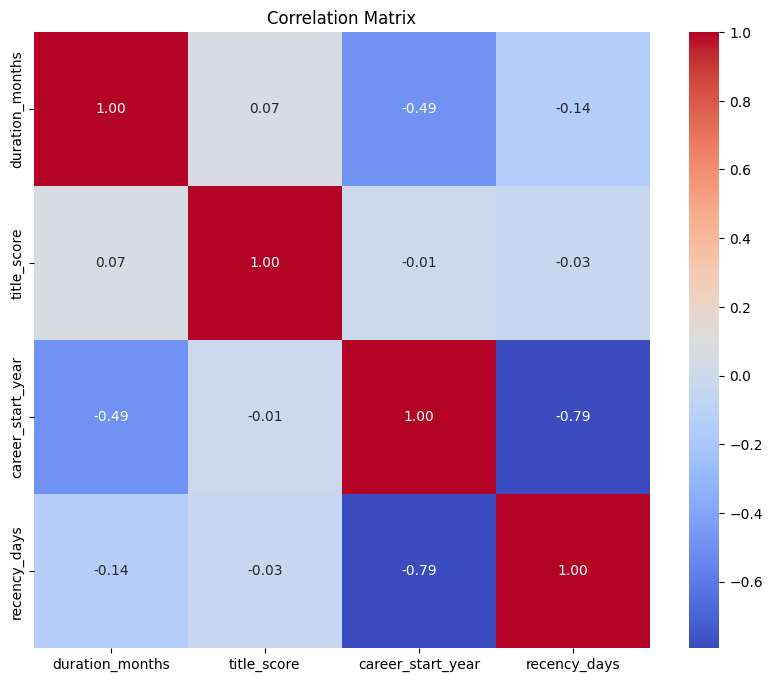

In [518]:
numeric_features = df_clean.select_dtypes(include=['number'])

corr_matrix = numeric_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()


In [519]:
df_clean.columns

Index(['first_name', 'last_name', 'headline', 'job_title',
       'time_type_full_or_part', 'duration_of_cooperation', 'location_hybrid',
       'company_name', 'duration_of_cooperation_clean', 'duration_text',
       'start_date', 'end_date', 'duration_months', 'experience_level',
       'time_type_Full-time', 'time_type_Other', 'time_type_Part-time',
       'time_type_Unknown', 'title_score', 'career_start_year', 'recency_days',
       'time_type_Full-time', 'time_type_Other', 'time_type_Part-time',
       'time_type_Unknown'],
      dtype='object')

In [520]:
df_clean = pd.get_dummies(df_clean, columns=['title_score'], prefix='time_type')


In [521]:
feature_cols = ['duration_months', 'time_type_Full-time', 'time_type_Other', 'time_type_Part-time',
       'time_type_Unknown', 'career_start_year', 'recency_days','time_type_1', 'time_type_2', 'time_type_3',
       'time_type_4', 'time_type_5'
       ]



X = df_clean[feature_cols]
y = df_clean['experience_level']


In [522]:
X

,duration_months,time_type_Full-time,time_type_Full-time,time_type_Other,time_type_Other,time_type_Part-time,time_type_Part-time,time_type_Unknown,time_type_Unknown,career_start_year,recency_days,time_type_1,time_type_2,time_type_3,time_type_4,time_type_5
0,25,False,False,True,True,False,False,False,False,2022,0,False,True,False,False,False
1,20,False,False,True,True,False,False,False,False,2022,0,False,False,False,True,False
2,21,True,True,False,False,False,False,False,False,2020,1018,False,True,False,False,False
3,52,False,False,False,False,False,False,True,True,2020,0,False,True,False,False,False
4,79,False,False,False,False,True,True,False,False,2018,0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,239,True,True,False,False,False,False,False,False,2004,0,False,True,False,False,False
12996,239,True,True,False,False,False,False,False,False,2004,0,False,False,False,True,False
12997,254,False,False,False,False,False,False,True,True,2003,0,False,True,False,False,False
12998,12,False,False,False,False,False,False,True,True,2023,0,False,True,False,False,False


In [523]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  
)


In [524]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [525]:
y_test_pred = knn.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

      Junior       0.98      0.99      0.99      1529
   Mid-level       0.95      0.92      0.93       368
      Senior       0.98      0.96      0.97       217

    accuracy                           0.98      2114
   macro avg       0.97      0.96      0.96      2114
weighted avg       0.98      0.98      0.98      2114



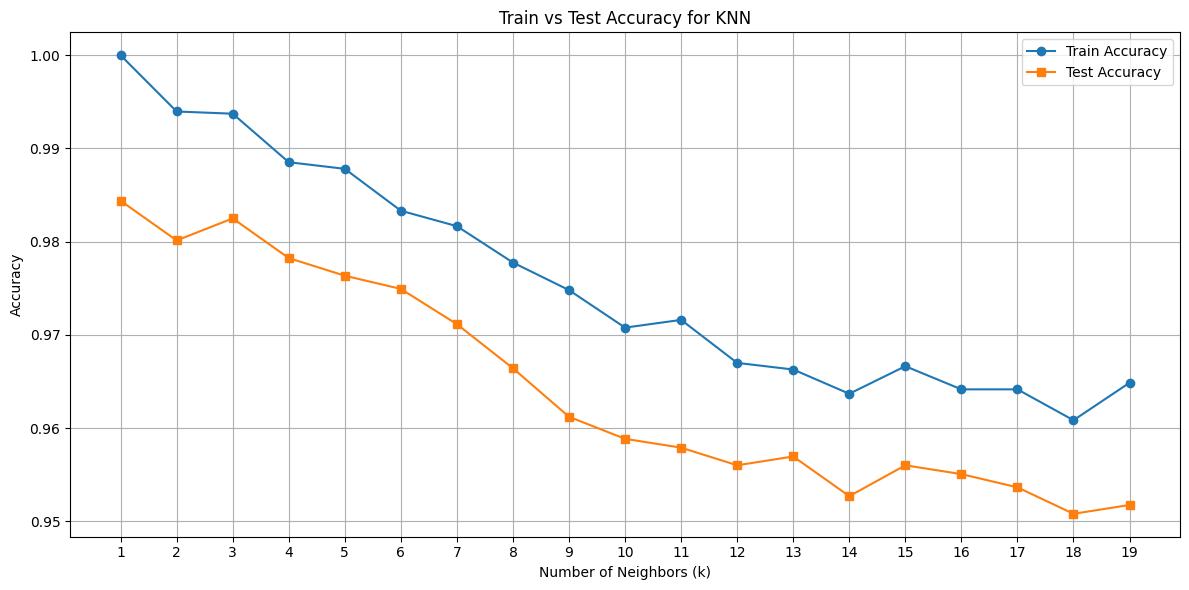

In [526]:

k_range = range(1, 20)
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)

    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)


plt.figure(figsize=(12, 6))
plt.plot(k_range, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_range, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy for KNN')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [527]:
best_k = k_range[test_accuracies.index(max(test_accuracies))]
best_acc = max(test_accuracies)
print("Best k:", best_k, "with Test Accuracy:", round(best_acc * 100, 2), "%")


Best k: 1 with Test Accuracy: 98.44 %


In [528]:
y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc * 100, 2), "%")

Accuracy: 95.18 %


In [529]:
X_test_scaled.shape

(2114, 16)

In [530]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ks = [1, 3, 5, 7]

for k in ks:
    print(f"\n========== K = {k} ==========")
    model = KNeighborsClassifier(n_neighbors=k)
    
    acc_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    f1_scores  = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_macro')

    print(f"Accuracy Mean:     {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"F1 Macro Mean:     {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")



========== K = 1 ==========
Accuracy Mean:     0.9883 ± 0.0023
F1 Macro Mean:     0.9807 ± 0.0044

========== K = 3 ==========
Accuracy Mean:     0.9802 ± 0.0038
F1 Macro Mean:     0.9683 ± 0.0067

========== K = 5 ==========
Accuracy Mean:     0.9726 ± 0.0019
F1 Macro Mean:     0.9553 ± 0.0040

========== K = 7 ==========
Accuracy Mean:     0.9644 ± 0.0043
F1 Macro Mean:     0.9428 ± 0.0080


In [531]:
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Confusion Matrix:
[[1520    9    0]
 [  17  348    3]
 [   0    4  213]]

Classification Report:
              precision    recall  f1-score   support

      Junior       0.99      0.99      0.99      1529
   Mid-level       0.96      0.95      0.95       368
      Senior       0.99      0.98      0.98       217

    accuracy                           0.98      2114
   macro avg       0.98      0.97      0.98      2114
weighted avg       0.98      0.98      0.98      2114



C:\Users\hwi\AppData\Local\Temp\ipykernel_10980\1706152868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='experience_level', palette='Set2', order=df['experience_level'].value_counts().index)


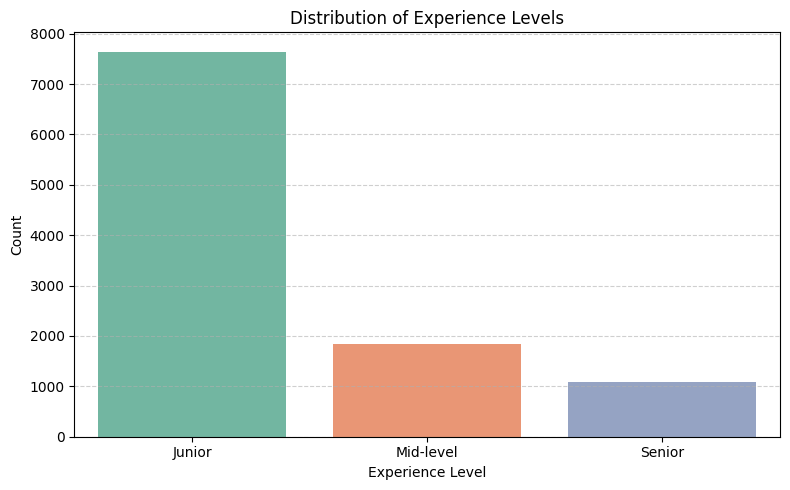

In [532]:


plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='experience_level', palette='Set2', order=df['experience_level'].value_counts().index)
plt.title('Distribution of Experience Levels')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [533]:

precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')
accuracy  = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")


Accuracy : 0.9844
Precision: 0.9797
Recall   : 0.9738


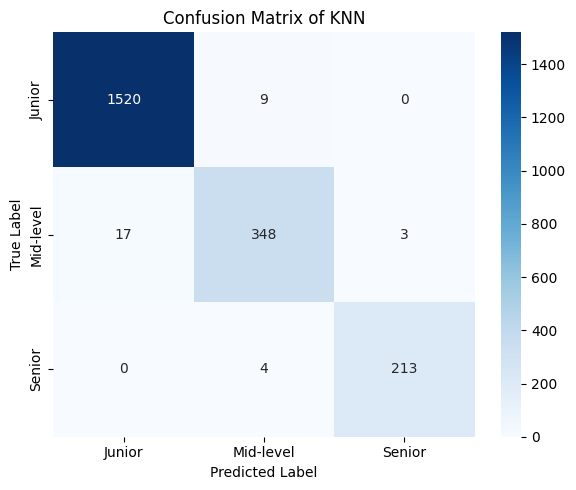

In [534]:



cm = confusion_matrix(y_test, y_pred, labels=['Junior', 'Mid-level', 'Senior'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Junior', 'Mid-level', 'Senior'],
            yticklabels=['Junior', 'Mid-level', 'Senior'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of KNN')
plt.tight_layout()
plt.show()


In [535]:
df_clean['experience_level_num'] = df_clean['experience_level'].map({
    'Junior': 0,
    'Mid-level': 1,
    'Senior': 2
})


In [536]:
df_clean[['experience_level', 'experience_level_num']]


,experience_level,experience_level_num
0,Junior,0
1,Junior,0
2,Junior,0
3,Mid-level,1
4,Senior,2
...,...,...
12995,Senior,2
12996,Senior,2
12997,Senior,2
12998,Junior,0


In [537]:
feature_cols = ['duration_months', 'time_type_Full-time', 'time_type_Other', 'time_type_Part-time',
       'time_type_Unknown', 'career_start_year', 'recency_days','time_type_1', 'time_type_2', 'time_type_3',
       'time_type_4', 'time_type_5'
       ]



X = df_clean[feature_cols]
y = df_clean['experience_level']


In [539]:

X_exp = df_clean[['duration_months']]
y_exp = df_clean['experience_level_num']

X_train, X_test, y_train, y_test = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_cont = lr.predict(X_test)

y_pred_class = np.round(y_pred_cont).clip(0, 2).astype(int)  

acc = accuracy_score(y_test, y_pred_class)
rmse = mean_squared_error(y_test, y_pred_cont, squared=False)

print(f"Accuracy (Rounded): {acc:.4f}")
print(f"RMSE: {rmse:.4f}")


Accuracy (Rounded): 0.9073
RMSE: 0.3427


c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [540]:
mapping = {'Junior': 0, 'Mid-level': 1, 'Senior': 2}
y_test_num = y_test.map(mapping)


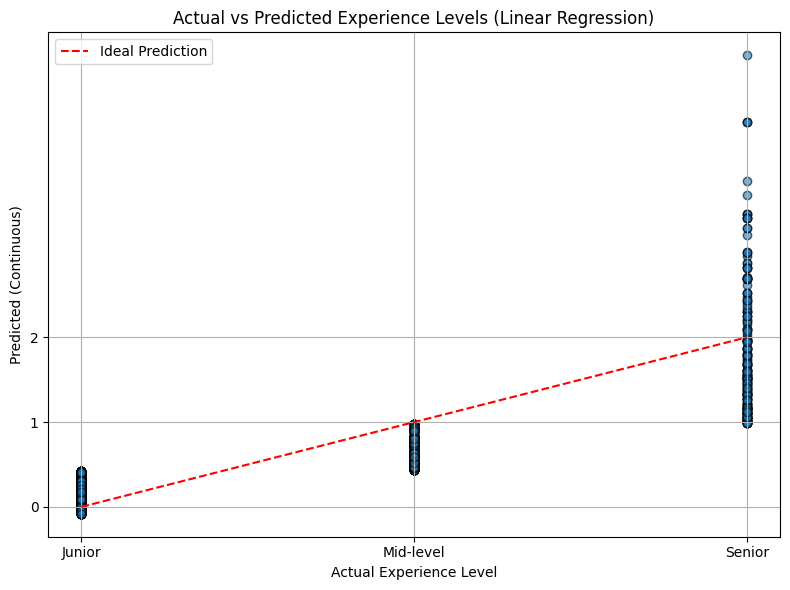

In [541]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_cont, alpha=0.6, edgecolors='k')
plt.plot([0, 2], [0, 2], color='red', linestyle='--', label='Ideal Prediction')
plt.xticks([0, 1, 2], ['Junior', 'Mid-level', 'Senior'])
plt.yticks([0, 1, 2])
plt.xlabel('Actual Experience Level')
plt.ylabel('Predicted (Continuous)')
plt.title('Actual vs Predicted Experience Levels (Linear Regression)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [542]:

X = df_clean[feature_cols]
y = df_clean['experience_level_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [543]:

log_reg = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, multi_class='multinomial')

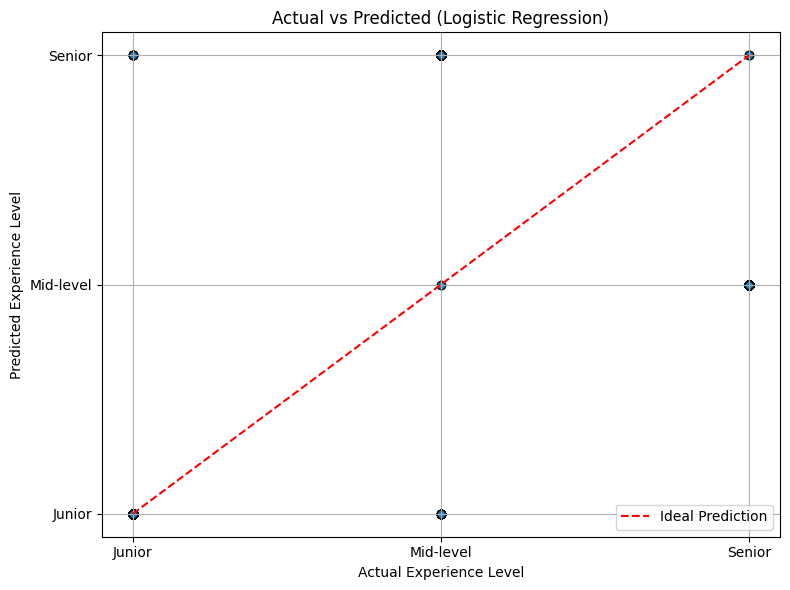

In [544]:

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([0, 2], [0, 2], color='red', linestyle='--', label='Ideal Prediction')

plt.xticks([0, 1, 2], ['Junior', 'Mid-level', 'Senior'])
plt.yticks([0, 1, 2], ['Junior', 'Mid-level', 'Senior'])
plt.xlabel("Actual Experience Level")
plt.ylabel("Predicted Experience Level")
plt.title("Actual vs Predicted (Logistic Regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [545]:


y_pred = log_reg.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Logistic Regression Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1529
           1       1.00      1.00      1.00       368
           2       1.00      1.00      1.00       217

    accuracy                           1.00      2114
   macro avg       1.00      1.00      1.00      2114
weighted avg       1.00      1.00      1.00      2114


Confusion Matrix:
[[1529    0    0]
 [   0  368    0]
 [   0    0  217]]


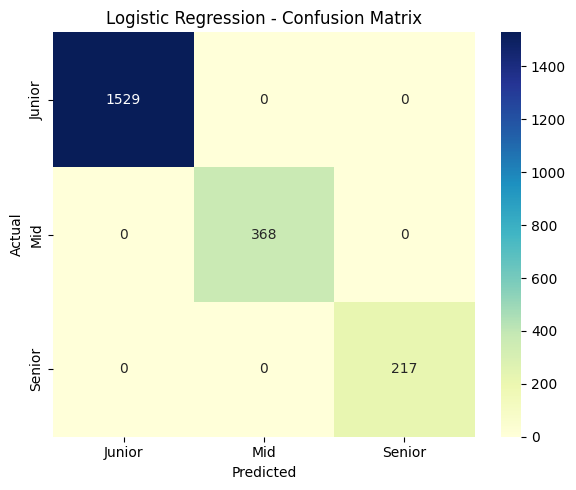

In [546]:


plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=['Junior', 'Mid', 'Senior'],
            yticklabels=['Junior', 'Mid', 'Senior'],
            cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()


In [547]:

mse_log = mean_squared_error(y_test, y_pred)
r2_log = r2_score(y_test, y_pred)
rmse = mse ** 0.5
print(f"Logistic Regression MSE: {mse_log:.4f}")
print(f"Logistic Regression RMSE: {mse_log:.4f}")
print(f"Logistic Regression R² : {r2_log:.4f}")


Logistic Regression MSE: 0.0000
Logistic Regression RMSE: 0.0000
Logistic Regression R² : 1.0000
